# Automotive Recall System — Exploratory Data Analysis

answering these 5 main questions:
1. How is data distributed across manufacturers and years?
2. Which components dominate complaints vs recalls?
3. What is the recall rate per manufacturer?
4. What does complaint text look like?
5. Are there data quality issues we need to fix?

In [ ]:
import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd()))

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

DB_PATH = "../data/automotive_recall.db"
conn    = sqlite3.connect(DB_PATH)

complaints = pd.read_sql_query("SELECT * FROM complaints", conn)
recalls    = pd.read_sql_query("SELECT * FROM recalls",    conn)
conn.close()

# Clean up booleans
complaints["crash"] = complaints["crash"].astype(bool)
complaints["fire"]  = complaints["fire"].astype(bool)

print(f"Complaints : {len(complaints):,} rows")
print(f"Recalls    : {len(recalls):,} rows")
print(f"Date range : {complaints['model_year'].min()} – {complaints['model_year'].max()}")
print(f"Manufacturers: {complaints['make'].nunique()}")

Complaints : 179,401 rows
Recalls    : 1,430 rows
Date range : 2015 – 2025
Manufacturers: 20


## 1. Complaints by Manufacturer

Which manufacturers have the most complaints? This tells us which brands are well-represented in our training data.

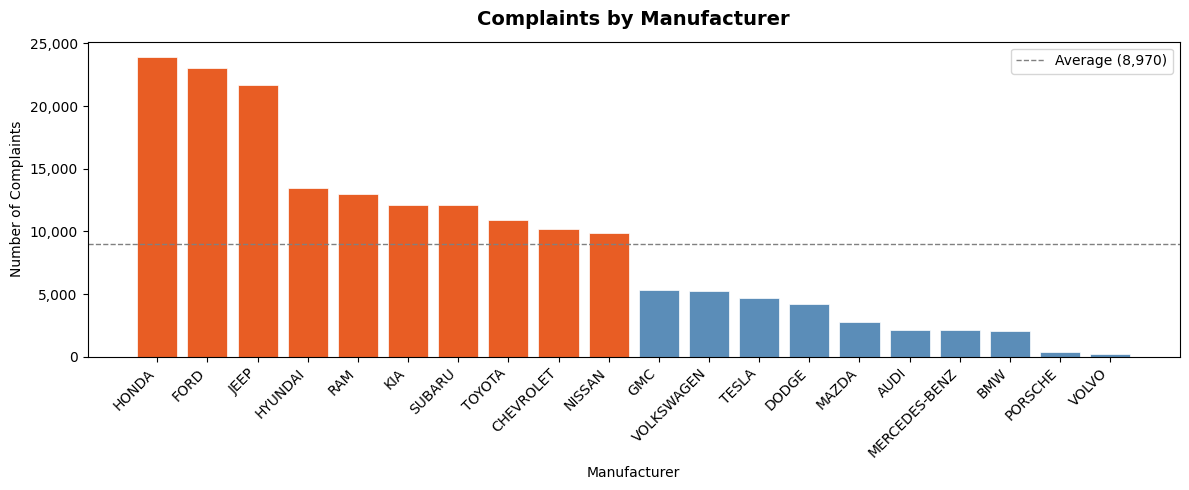

Top 5 manufacturers:
make
HONDA      23945
FORD       23002
JEEP       21694
HYUNDAI    13430
RAM        13007
Name: count, dtype: int64
HONDA dominates with 23,945 complaints (13.3% of total)


In [7]:
fig, ax = plt.subplots(figsize=(12, 5))

counts = complaints["make"].value_counts()
colors = ["#E85D24" if c > counts.mean() else "#5B8DB8" for c in counts.values]

bars = ax.bar(counts.index, counts.values, color=colors, edgecolor="white", linewidth=0.5)
ax.axhline(counts.mean(), color="gray", linestyle="--", linewidth=1, label=f"Average ({counts.mean():,.0f})")

ax.set_title("Complaints by Manufacturer", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Manufacturer")
ax.set_ylabel("Number of Complaints")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.xticks(rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.savefig("complaints_by_make.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 5 manufacturers:")
print(counts.head())
print(f"{counts.idxmax()} dominates with {counts.max():,} complaints ({counts.max()/len(complaints)*100:.1f}% of total)")


## 2. Complaints by Year

Are complaints spread across years or concentrated? Thin data for recent years means the model may struggle to predict recalls for newer vehicles.

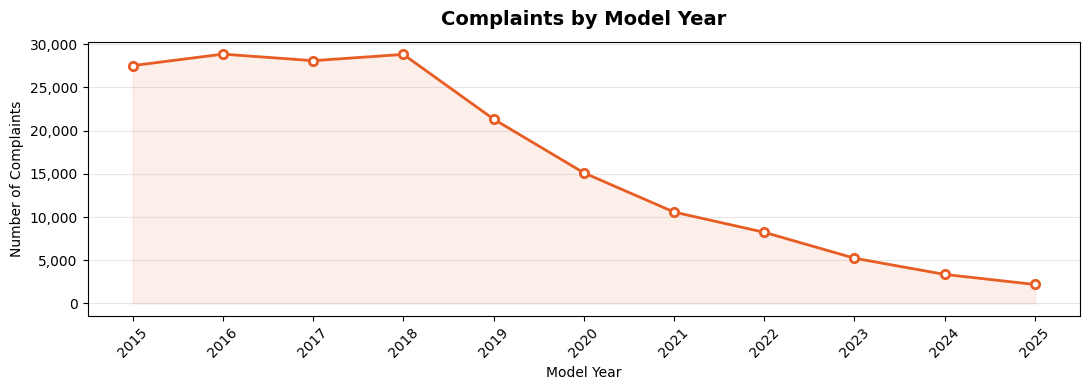

Peak year     : 2016 (28,859 complaints)
Most recent   : 2025 (2,197 complaints)
Recent years (2023+) likely have fewer complaints — vehicles are new


In [8]:
fig, ax = plt.subplots(figsize=(11, 4))

year_counts = complaints["model_year"].value_counts().sort_index()
ax.plot(year_counts.index, year_counts.values, marker="o", color="#E85D24",
        linewidth=2, markersize=6, markerfacecolor="white", markeredgewidth=2)
ax.fill_between(year_counts.index, year_counts.values, alpha=0.1, color="#E85D24")

ax.set_title("Complaints by Model Year", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Model Year")
ax.set_ylabel("Number of Complaints")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_xticks(year_counts.index)
plt.xticks(rotation=45)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("complaints_by_year.png", dpi=150, bbox_inches="tight")
plt.show()

peak_year = year_counts.idxmax()
print(f"Peak year     : {peak_year} ({year_counts[peak_year]:,} complaints)")
print(f"Most recent   : {year_counts.index[-1]} ({year_counts.iloc[-1]:,} complaints)")
print(f"Recent years (2023+) likely have fewer complaints — vehicles are new")

## 3. Recall Rate by Manufacturer

This is the most important chart for our ML model. What percentage of complaints per manufacturer actually led to a recall? This reveals which brands are highest risk and sets our baseline prediction target.

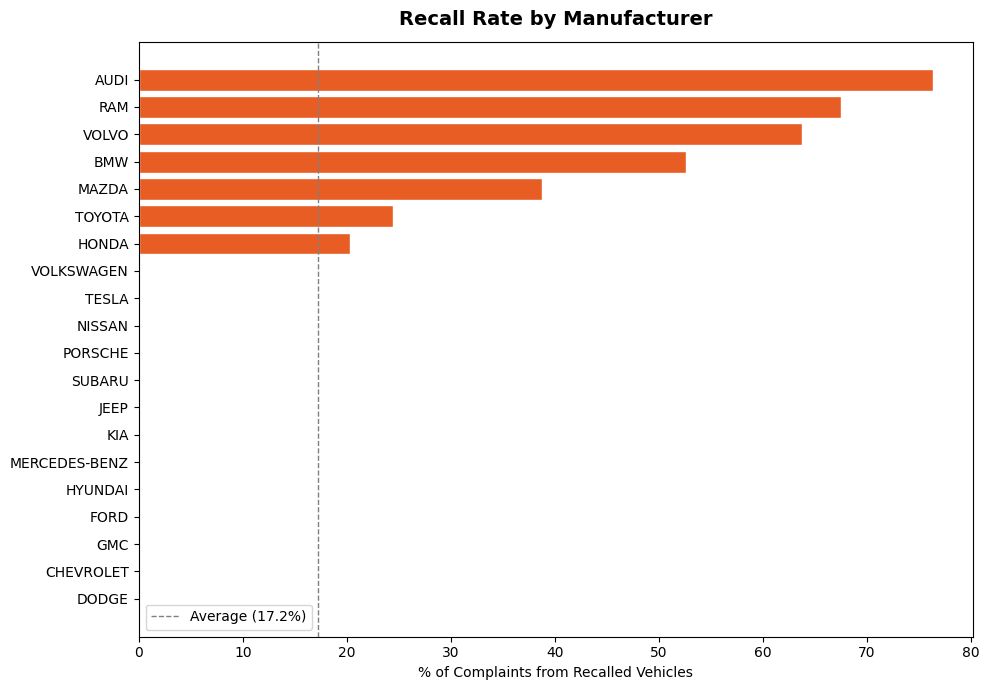

Overall recall rate : 11.3%
Highest risk: AUDI (76.4%)
Lowest risk : DODGE (0.0%)
Overall rate of 11.3% means strong class imbalance — model must handle this


In [9]:
# Build vehicle-level flags: did this make/model/year ever get recalled?
recalled_vehicles = set(
    zip(recalls["make"], recalls["model"], recalls["model_year"])
)
complaints["was_recalled"] = complaints.apply(
    lambda r: (r["make"], r["model"], r["model_year"]) in recalled_vehicles, axis=1
)

recall_stats = complaints.groupby("make").agg(
    total_complaints = ("odi_number", "count"),
    recalled         = ("was_recalled", "sum")
).reset_index()
recall_stats["recall_rate"] = recall_stats["recalled"] / recall_stats["total_complaints"] * 100
recall_stats = recall_stats.sort_values("recall_rate", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#E85D24" if r > recall_stats["recall_rate"].mean() else "#5B8DB8"
          for r in recall_stats["recall_rate"]]
ax.barh(recall_stats["make"], recall_stats["recall_rate"], color=colors, edgecolor="white")
ax.axvline(recall_stats["recall_rate"].mean(), color="gray", linestyle="--", linewidth=1,
           label=f"Average ({recall_stats['recall_rate'].mean():.1f}%)")

ax.set_title("Recall Rate by Manufacturer", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("% of Complaints from Recalled Vehicles")
ax.legend()
plt.tight_layout()
plt.savefig("recall_rate_by_make.png", dpi=150, bbox_inches="tight")
plt.show()

overall_rate = complaints["was_recalled"].mean() * 100
print(f"Overall recall rate : {overall_rate:.1f}%")
print(f"Highest risk: {recall_stats.iloc[-1]['make']} ({recall_stats.iloc[-1]['recall_rate']:.1f}%)")
print(f"Lowest risk : {recall_stats.iloc[0]['make']} ({recall_stats.iloc[0]['recall_rate']:.1f}%)")
print(f"Overall rate of {overall_rate:.1f}% means strong class imbalance — model must handle this")


**Observation:** The overall recall rate is the single most important number for ML. If only 5% of complaints lead to recalls, a model that always predicts "no recall" would be 95% accurate but completely useless.

## 4. Top Components — Complaints vs Recalls

Which components generate the most complaints? Which components most commonly trigger recalls? If these differ, it tells us which components are strong predictive signals.

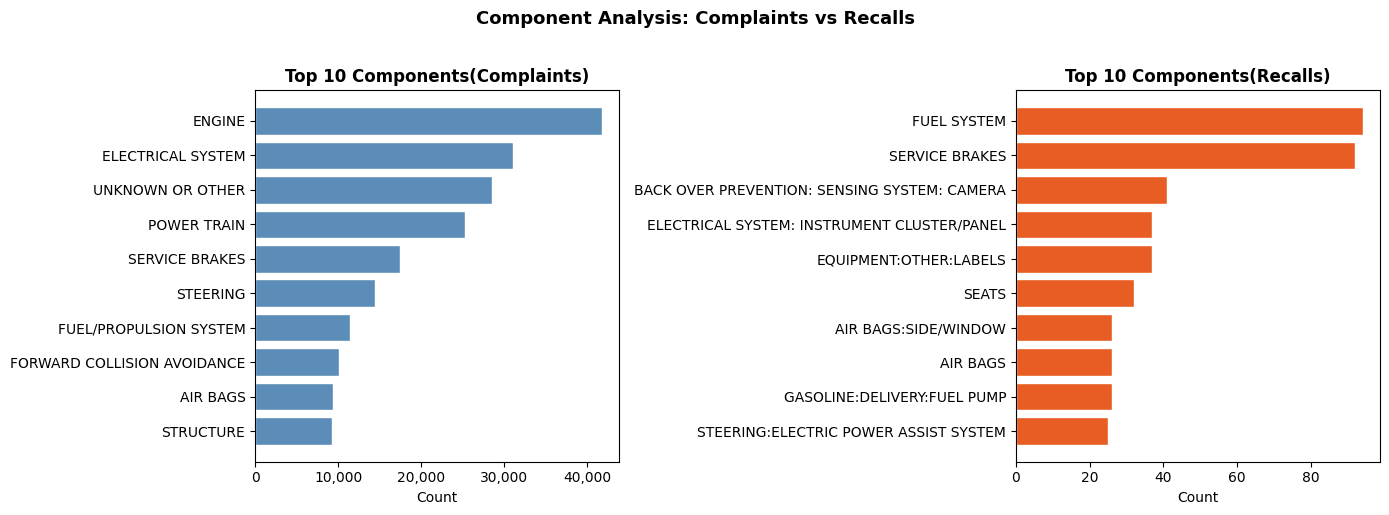

Components in top 10 of BOTH complaints and recalls:
  SERVICE BRAKES
  AIR BAGS
These overlapping components are likely strong ML features


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Complaints — top 10 components
comp_counts = (complaints["component"]
               .str.split(",").explode()
               .str.strip().str.upper()
               .value_counts().head(10))
ax1.barh(comp_counts.index[::-1], comp_counts.values[::-1], color="#5B8DB8", edgecolor="white")
ax1.set_title("Top 10 Components(Complaints)", fontweight="bold")
ax1.set_xlabel("Count")
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Recalls — top 10 components
rec_counts = (recalls["component"]
              .str.split(",").explode()
              .str.strip().str.upper()
              .value_counts().head(10))
ax2.barh(rec_counts.index[::-1], rec_counts.values[::-1], color="#E85D24", edgecolor="white")
ax2.set_title("Top 10 Components(Recalls)", fontweight="bold")
ax2.set_xlabel("Count")

plt.suptitle("Component Analysis: Complaints vs Recalls", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("component_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# Find components that appear in BOTH top lists
overlap = set(comp_counts.index) & set(rec_counts.index)
print(f"Components in top 10 of BOTH complaints and recalls:")
for c in overlap:
    print(f"  {c}")
print(f"These overlapping components are likely strong ML features")


**Observation:** Components appearing in the top 10 of both lists are your strongest predictive features. If a component drives lots of complaints AND lots of recalls, the model should weight it heavily.

## 5. Data Quality Check

Before building the ML model we must understand what is broken in the data. Missing summaries, very short text, and suspicious values all need to be caught now.

In [ ]:
print("=" * 50)
print("DATA QUALITY REPORT")
print("=" * 50)

total = len(complaints)

# Missing summaries
null_summary = complaints["summary"].isna().sum()
empty_summary = (complaints["summary"].str.strip() == "").sum()
print(f"[1] Summary field (main ML input)")
print(f"    Null    : {null_summary:,} ({null_summary/total*100:.1f}%)")
print(f"    Empty   : {empty_summary:,} ({empty_summary/total*100:.1f}%)")

# Summary length distribution
complaints["summary_len"] = complaints["summary"].fillna("").str.split().str.len()
short = (complaints["summary_len"] < 10).sum()
print(f"    < 10 words : {short:,} ({short/total*100:.1f}%) — too short for NLP, will drop")
print(f"    Median length : {complaints['summary_len'].median():.0f} words")
print(f"    Max length    : {complaints['summary_len'].max():.0f} words")

# Missing component
null_component = complaints["component"].isna().sum()
unknown_component = (complaints["component"] == "UNKNOWN").sum()
print(f"[2] Component field")
print(f"    Null/Unknown : {null_component + unknown_component:,} ({(null_component+unknown_component)/total*100:.1f}%)")

# serious flags
crashes  = complaints["crash"].sum()
fires    = complaints["fire"].sum()
injuries = complaints["injuries"].sum()
deaths   = complaints["deaths"].sum()
print(f"[3] Severity signals")
print(f"    Crashes  : {crashes:,} ({crashes/total*100:.1f}%)")
print(f"    Fires    : {fires:,} ({fires/total*100:.1f}%)")
print(f"    Injuries : {injuries:,}")
print(f"    Deaths   : {deaths:,}")

# Summary 
print(f"{'='*50}")
print("actions to be taken during pre-processing:")
print(f"  1. Drop {short:,} complaints with < 10 word summaries")
print(f"  2. Fill missing component with UNKNOWN before encoding")
print(f"  3. Handle class imbalance — recall rate is very low")
print(f"  4. Clean summary text: lowercase, remove punctuation")


DATA QUALITY REPORT
[1] Summary field (main ML input)
    Null    : 0 (0.0%)
    Empty   : 0 (0.0%)
    < 10 words : 5,373 (3.0%) — too short for NLP, will drop
    Median length : 84 words
    Max length    : 720 words
[2] Component field
    Null/Unknown : 0 (0.0%)
[3] Severity signals
    Crashes  : 7,870 (4.4%)
    Fires    : 2,316 (1.3%)
    Injuries : 6,645
    Deaths   : 106
actions to be taken during pre-processing:
  1. Drop 5,373 complaints with < 10 word summaries
  2. Fill missing component with UNKNOWN before encoding
  3. Handle class imbalance — recall rate is very low
  4. Clean summary text: lowercase, remove punctuation
